# Análise Scada Café

### Calendário:

In [1]:
# Calcular fim do mês:
import datetime

hoje = datetime.date.today()
ano = hoje.year
mes = hoje.month
# Calcular último dia do mês corrente:
if mes == 12:
    ultimo_dia = datetime.date(ano + 1, 1, 1) - datetime.timedelta(days=1)
else:
    ultimo_dia = datetime.date(ano, mes + 1, 1) - datetime.timedelta(days=1)
# Calcular dias restantes:
dias_restantes = (ultimo_dia - hoje).days

print(f"Faltam {dias_restantes} dias para terminar o mês.")


Faltam 21 dias para terminar o mês.


## Importação de base

In [2]:
import pandas as pd

faturamento_df = pd.read_excel("base_cinema.xlsx")
produtos_df = pd.read_excel('base_cinema_produtos.xlsx')
perdas_df = pd.read_excel('base_cinema_perdas.xlsx')
perdas_df = pd.read_excel('base_cinema_perdas.xlsx')

#faturamento_df.info()
#produtos_df.info()

#perdas_df.info()
#display(perdas_df)
#display(perdas_df_bps)
display(perdas_df)

,Data,Item,Quantidade,Valor (R$),Motivo,Responsavel,Observação,MÊS/ANO
0,2025-04-01 00:00:00,LEITE,0.065,0.38935,Venceu (Validade),COZINHA,AZEDO,04/2025
1,2025-04-01 00:00:00,RUCULA,0.064,0.21696,Outro,COZINHA,MURCHA E AMARELA,04/2025
2,2025-04-02 00:00:00,ALFACE,0.300,2.09400,Outro,COZINHA,AMARELADO,04/2025
3,2025-04-02 00:00:00,TOMATE,0.200,2.19800,Outro,COZINHA,AZEDO,04/2025
4,2025-04-03 00:00:00,VEG MATCHA GELADO,1.000,7.46000,Outro,EQUIPE,ENTREGADOR DERRAMOU,04/2025
...,...,...,...,...,...,...,...,...
539,2025-12-09 00:00:00,MANJERICAO,0.034,NaN,Venceu (Validade),JESIANA,muchou,12/2025
540,2025-12-09 00:00:00,PAO DE QUEIJO PORÇAO,2.000,NaN,Venceu (Validade),JESIANA,mofou,12/2025
541,2025-12-09 00:00:00,PAO DE QUEIJO UNIDADE,2.000,NaN,Venceu (Validade),JESIANA,mofou,12/2025
542,2025-12-09 00:00:00,Bolo Maça,1.000,NaN,Erro de processo,FABIO,Entrou água da geladeira no bolo.,12/2025


## Tratamento de dados

In [3]:
import locale
locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')

faturamento_df = faturamento_df.rename(columns={'Cupom Total': 'Cupons por Dia'}) # Renomear uma coluna
faturamento_df["% Meta"] = faturamento_df["Faturamento"] / faturamento_df["Meta"] * 100 # Acrescentando uma coluna com percentual da meta

#faturamento_df['Mês'] = pd.to_datetime(faturamento_df["Mês"], format='%Y-%m-%d')
faturamento_df["Mês"] = faturamento_df["Mês"].dt.month_name(locale="pt_BR.UTF-8") # Substituir formato da coluna Mês atual por descrição do mês
faturamento_df["Dia Semana"] = faturamento_df["Dia"].dt.day_name(locale='pt_BR.UTF-8') # Acrescentar coluna com dias da semana

#display(faturamento_df)
#faturamento_df.info()
#faturamento_df.describe()

In [4]:
produtos_df["Mês"] = produtos_df["Mês"].dt.month_name(locale="pt_BR.UTF-8") # Substituir formato da coluna Mês atual por descrição do mês
#display(produtos_df) # Exibição simples do Dataframe
#produtos_df.info()

In [5]:
# Renomear colunas
perdas_df = perdas_df.rename(columns={'Item (Descrição do item da perda)': 'Item'})
perdas_df = perdas_df.rename(columns={'Quantidade (Qtd, peso, etc)': 'Quantidade'})
perdas_df = perdas_df.rename(columns={'Observação (Detalhamento. O que aconteceu?)': 'Observação'})

# Tratamento dados cinema:
#perdas_df = perdas_df.rename(columns={'MÊS/ANO': 'Mês'}) #Renomear coluna
perdas_df = perdas_df.rename(columns={'Data': 'Data da perda'}) #Renomear coluna
perdas_df = perdas_df.rename(columns={'Responsavel': 'Responsável'}) #Renomear coluna
# Excluir coluna de data:
perdas_df = perdas_df.drop("MÊS/ANO", axis=1)


# Substituir formato da coluna Mês atual por descrição do mês
perdas_df["Mês"] = pd.to_datetime(perdas_df["Data da perda"], errors="coerce") # Converter coluna para formato Datetime
perdas_df["Data da perda"] = pd.to_datetime(perdas_df["Data da perda"], errors="coerce") # Converter coluna para formato Datetime
perdas_df["Mês"] = perdas_df["Mês"].dt.month_name(locale="pt_BR.utf8") # Alterar exibição para apenas o nome do mês

#perdas_df.info()
#display(perdas_df)
#display(perdas_df_bps)
#display(perdas_df)

# Analise Resultados

## Resultados Vendas:

### Por Mês:

In [6]:
ordem_meses = [
    "Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
    "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"
]

faturamento_por_mes = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index() # Gerar o somatório de faturamento por mês
#groupby("Mes") → agrupa as linhas por cada mês.
#["Faturamento"].sum() → soma os valores da coluna Faturamento dentro de cada grupo.
#.reset_index() → reorganiza o resultado em formato de tabela normal.

# Ordenar os meses de forma correta (crescente):
faturamento_por_mes["Mês"] = pd.Categorical(
    faturamento_por_mes["Mês"],
    categories=ordem_meses,
    ordered=True
)
faturamento_por_mes = faturamento_por_mes.sort_values("Mês")

display(faturamento_por_mes)

,Mês,Faturamento,Meta
4,Janeiro,117238.93,105090.04
3,Fevereiro,116941.63,108039.80
8,Março,111252.51,129407.46
0,Abril,76405.63,127575.39
7,Maio,89507.40,133367.08
6,Junho,73642.31,109785.17
5,Julho,77808.27,110664.58
1,Agosto,85609.93,110311.14
11,Setembro,71818.42,95022.48
10,Outubro,114227.53,99233.75


### Por Dia:

In [7]:
faturamento_por_dia = faturamento_df.groupby("Dia")["Faturamento"].sum().reset_index() # Gerar o somatório de faturamento por mês
#groupby("Mes") → agrupa as linhas por cada mês.
#["Faturamento"].sum() → soma os valores da coluna Faturamento dentro de cada grupo.
#.reset_index() → reorganiza o resultado em formato de tabela normal.

# Ordenar os meses de forma correta (crescente):
faturamento_por_dia["Dia"] = pd.Categorical(
    faturamento_por_dia["Dia"],
    #categories=ordem_meses,
    ordered=True
)
faturamento_por_dia = faturamento_por_dia.sort_values("Dia")

display(faturamento_por_dia)

,Dia,Faturamento
0,2025-01-01,0.00
1,2025-01-02,2801.25
2,2025-01-03,2801.51
3,2025-01-04,4097.75
4,2025-01-05,3457.81
...,...,...
360,2025-12-27,0.00
361,2025-12-28,0.00
362,2025-12-29,0.00
363,2025-12-30,0.00


### Por Dia da Semana:

In [8]:
df_validos = faturamento_df[faturamento_df["Faturamento"] > 0]
faturamento_medio_semana = df_validos.groupby("Dia Semana")["Faturamento"].mean().reset_index()
#ordem_dias_semana = ["Segunda feira", "Terça feira", "Quarta feira", "Quinta feira", "Sexta feira", "Sábado", "Domingo"]
ordem_dias_semana = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]
faturamento_medio_semana["Dia Semana"] = pd.Categorical(
    faturamento_medio_semana["Dia Semana"],
    categories=ordem_dias_semana,
    ordered=True
)
faturamento_medio_semana = faturamento_medio_semana.sort_values("Dia Semana")

faturamento_medio_semana["Faturamento"] = faturamento_medio_semana["Faturamento"].round(2)

display(faturamento_medio_semana)

,Dia Semana,Faturamento
3,Segunda,2416.08
6,Terça,2435.95
1,Quarta,2880.17
2,Quinta,3001.43
4,Sexta,2782.10
5,Sábado,4122.41
0,Domingo,3797.17


### Por produtos (mais vendidos no Ano e no Mês):

In [9]:
produtos_por_mes = produtos_df.loc[produtos_df['Mês'] == "Novembro", :] # Filtrar os dados do mês desejado
produtos_por_mes = produtos_por_mes.sort_values("Valor Total", ascending=False)

total_fat_ano = faturamento_df["Faturamento"].sum()

produtos_ano = produtos_df.groupby("Produto")["Valor Total"].sum().reset_index() # Somar o valor total por produto no ano
produtos_ano = produtos_ano.sort_values("Valor Total", ascending=False)
produtos_ano["% do Fat Total"] = produtos_ano["Valor Total"] / total_fat_ano #inserir coluna com percentual
produtos_ano["Média Fat Mensal"] = produtos_ano["Valor Total"] / mes #inserir coluna com média mensal

def formatar(valor): # Função para formatar valores em reais
    valor_formatado = f"R$ {valor:,.2f}"
    return valor_formatado

def formatar_perc(percentual): # Função para formatar valores percentuais
    percentual_formatado = f"{percentual:.2%}"
    return percentual_formatado

produtos_ano["Valor Total"] = produtos_ano["Valor Total"].apply(formatar)
produtos_ano["Média Fat Mensal"] = produtos_ano["Média Fat Mensal"].apply(formatar)
produtos_ano["% do Fat Total"] = produtos_ano["% do Fat Total"].apply(formatar_perc)

print(f"Faturamento Total Ano: R$ {total_fat_ano:,.2f}")
print("Produtos mais vendidos do Ano:")
display(produtos_ano.head(10)) # Exibir os 10 produtos mais vendidos do Ano
print("Produtos mais vendidos do Mês:")
display(produtos_por_mes.head(10))

Faturamento Total Ano: R$ 1,047,449.62
Produtos mais vendidos do Ano:


,Produto,Valor Total,% do Fat Total,Média Fat Mensal
132,ESPRESSO SIMPLES,"R$ 85,665.00",8.18%,"R$ 7,138.75"
167,PAO QUEIJO PORCAO,"R$ 28,056.00",2.68%,"R$ 2,338.00"
73,CAPPUCCINO ITALIANO DUPLO,"R$ 24,942.00",2.38%,"R$ 2,078.50"
169,PAO QUEIJO UNID,"R$ 23,690.00",2.26%,"R$ 1,974.17"
129,ESPRESSO DUPLO,"R$ 22,982.50",2.19%,"R$ 1,915.21"
29,AGUA GARRAFA C/ GAS,"R$ 21,411.00",2.04%,"R$ 1,784.25"
30,AGUA GARRAFA S/ GAS,"R$ 21,036.50",2.01%,"R$ 1,753.04"
45,BOLO LARANJA,"R$ 20,864.50",1.99%,"R$ 1,738.71"
130,ESPRESSO LATTE DUPLO,"R$ 19,657.50",1.88%,"R$ 1,638.12"
113,COCA ZERO LATA,"R$ 15,820.00",1.51%,"R$ 1,318.33"


Produtos mais vendidos do Mês:


,Mês,Cód.,Produto,Un.,Qtde.,Valor Unit.,Valor Total,% Total Venda,MTC
1980,Novembro,1,ESPRESSO SIMPLES,UN,761,10.00,7610.0,9.09,401.58
1981,Novembro,1007,PAO QUEIJO PORCAO,UN,130,19.15,2490.0,2.97,68.60
1982,Novembro,1006,PAO QUEIJO UNID,UN,176,13.00,2288.0,2.73,92.88
1983,Novembro,9621,CROISSANT PARMA,UN,57,37.00,2109.0,2.52,30.08
1984,Novembro,2,ESPRESSO DUPLO,UN,135,15.50,2092.5,2.50,71.24
1985,Novembro,315,CAPPUCCINO ITALIANO DUPLO,UN,110,18.50,2035.0,2.43,58.05
1986,Novembro,605,AGUA GARRAFA C/ GAS,UN,237,8.50,2014.5,2.41,125.07
1987,Novembro,604,AGUA GARRAFA S/ GAS,UN,210,8.50,1785.0,2.13,110.82
1988,Novembro,1070,CROISSANT MISTO,UN,64,27.00,1728.0,2.06,33.77
1989,Novembro,1202,BOLO LARANJA,UN,101,16.50,1666.5,1.99,53.30


### Criação de variáveis e funções

In [10]:
# Dados de Comissão:
dados_comissao = {
    "mes_atual": [
        {'Data': '01/12/25', 'Comissao': 356, 'EquipeDia': 10},
        {'Data': '02/12/25', 'Comissao': 232.35, 'EquipeDia': 10},
        {'Data': '03/12/25', 'Comissao': 283.38, 'EquipeDia': 10},
        {'Data': '04/12/25', 'Comissao': 366.60, 'EquipeDia': 10},
        {'Data': '05/12/25', 'Comissao': 265.20, 'EquipeDia': 10},
        {'Data': '06/12/25', 'Comissao': 386.35, 'EquipeDia': 10},
        {'Data': '07/12/25', 'Comissao': 286, 'EquipeDia': 9},
        {'Data': '08/12/25', 'Comissao': 257.55, 'EquipeDia': 9},
        {'Data': '09/12/25', 'Comissao': 317.20, 'EquipeDia': 9},
        
    ]
}

comissao_individual_equipe = round(sum((dia['Comissao'] / dia['EquipeDia']) * 0.80 for dia in dados_comissao["mes_atual"]), 2)
media_comissao_dia = round(sum((dia['Comissao'] / dia['EquipeDia']) * 0.80 for dia in dados_comissao["mes_atual"]) / len(dados_comissao["mes_atual"]),4)
projecao_comiss_mes = comissao_individual_equipe + (media_comissao_dia * (dias_restantes))

print('- DADOS COMISSÃO:')
print(f'Comissão individual acumulada: R$ {comissao_individual_equipe:,.2f}')
print(f'Média Comissão dia: R$ {media_comissao_dia:,.2f}')
print(f'Projeção Mês: R$ {projecao_comiss_mes:,.2f}')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')



- DADOS COMISSÃO:
Comissão individual acumulada: R$ 227.70
Média Comissão dia: R$ 25.30
Projeção Mês: R$ 759.00
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


In [11]:
# FILTRAR MES CORRENTE em:

df_mes_corrente = faturamento_df[
    (faturamento_df['Dia'].dt.year == 2025) &
    (faturamento_df['Dia'].dt.month == 12)
]

In [12]:
import calendar
import locale
# Configura o locale para Português do Brasil (Pode ser necessário dependendo do ambiente)
locale.setlocale(locale.LC_TIME, 'pt_BR.UTF-8') 
# Se a linha acima falhar, tente: locale.setlocale(locale.LC_TIME, 'portuguese')
# Método 2: Usando a biblioteca 'calendar' para ter controle do idioma
mes_numero = df_mes_corrente['Dia'].dt.month.iloc[0]
nome_do_mes_pt_br = calendar.month_name[mes_numero]
# Apenas para garantir que caso comece com letra maiúscula (o calendar.month_name retorna 'outubro')
nome_do_mes_corrente = nome_do_mes_pt_br.capitalize()

# VARIÁVEIS DE APOIO:
meta_mes_corrente = df_mes_corrente["Meta"].sum()
soma_faturamento = df_mes_corrente['Faturamento'].sum()
faturamento_medio_dia = df_mes_corrente['Faturamento'].mean()
total_cupons_mes = df_mes_corrente['Cupons por Dia'].sum()
ticket_medio_dia = soma_faturamento / total_cupons_mes
media_cupons_dia = df_mes_corrente['Cupons por Dia'].mean()
projecao_faturamento = soma_faturamento + (faturamento_medio_dia * dias_restantes)
ticket_meta_dia = (meta_mes_corrente - soma_faturamento) / total_cupons_mes * media_cupons_dia / dias_restantes
fat_meta_dia = (meta_mes_corrente - soma_faturamento) / dias_restantes
ticket_meta_dia = (meta_mes_corrente - soma_faturamento) / media_cupons_dia / dias_restantes
fat_total_eq_1 = df_mes_corrente[df_mes_corrente['Equipe'] == 1]['Faturamento'].sum()
fat_total_eq_2 = df_mes_corrente[df_mes_corrente['Equipe'] == 2]['Faturamento'].sum()
ticket_eq_1 = df_mes_corrente[df_mes_corrente['Equipe'] == 1]['Ticket Médio'].mean()
ticket_eq_2 = df_mes_corrente[df_mes_corrente['Equipe'] == 2]['Ticket Médio'].mean()
total_dias_eq_1 = df_mes_corrente[df_mes_corrente['Equipe'] == 1]['Dia'].nunique()
total_dias_eq_2 = df_mes_corrente[df_mes_corrente['Equipe'] == 2]['Dia'].nunique()


# Resumo Resultados:

In [13]:
# EXIBIÇÕES:
#comissao_outubro = calcular_comissao(dados_2025, mes_corrente)
#ticket_outubro = calcular_ticket(dados_2025, mes_corrente)
print(f'- DADOS FATURAMENTO - {nome_do_mes_corrente}:')
print(f'Meta Mês: R$ {meta_mes_corrente:,.2f}')
print(f'Faturamento: R$ {soma_faturamento:,.2f}')
print(f'% Meta: {soma_faturamento / meta_mes_corrente:.0%}')
print(f'Faturamento Médio Dia: R$ {faturamento_medio_dia:,.2f}')
print(f'Ticket Médio Dia: R$ {ticket_medio_dia:,.2f}')
print(f'Média Cupons Dia: {media_cupons_dia:.0f}')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('- PROJEÇÕES E RECUPERAÇÃO META:')
print(f'Ainda faltam R$ {meta_mes_corrente - soma_faturamento:,.2f} para atingirmos a  meta do mês.')
print(f'Estamos projetando R$ {projecao_faturamento:,.2f} de faturamento no mês.')
print(f'Precisamos de R$ {ticket_meta_dia:,.0f} por mesa ou R$ {fat_meta_dia:,.0f} por dia para alcançarmos a meta do mês.')
print(f'Isso representa R$ {ticket_meta_dia - ticket_medio_dia:,.0f} a mais por mesa mediante aos R$ {ticket_medio_dia:,.0f} realizado atualmente.')
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')
print('- RESULTADO POR EQUIPE:')
print(f'Faturamento Equipe 01: R$ {fat_total_eq_1:,.0f}')
print(f'Faturamento Equipe 02: R$ {fat_total_eq_2:,.0f}')
print(f'Ticket Médio Equipe 01: R$ {ticket_eq_1:,.0f}')
print(f'Ticket Médio Equipe 02: R$ {ticket_eq_2:,.0f}')
print(f"Dias trabalhados Equipe 1: {total_dias_eq_1}")
print(f"Dias trabalhados Equipe 2: {total_dias_eq_2}")
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -')


- DADOS FATURAMENTO - Dezembro:
Meta Mês: R$ 92,958.24
Faturamento: R$ 29,258.04
% Meta: 31%
Faturamento Médio Dia: R$ 3,250.89
Ticket Médio Dia: R$ 44.47
Média Cupons Dia: 73
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
- PROJEÇÕES E RECUPERAÇÃO META:
Ainda faltam R$ 63,700.20 para atingirmos a  meta do mês.
Estamos projetando R$ 97,526.80 de faturamento no mês.
Precisamos de R$ 41 por mesa ou R$ 3,033 por dia para alcançarmos a meta do mês.
Isso representa R$ -3 a mais por mesa mediante aos R$ 44 realizado atualmente.
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
- RESULTADO POR EQUIPE:
Faturamento Equipe 01: R$ 13,008
Faturamento Equipe 02: R$ 16,250
Ticket Médio Equipe 01: R$ 45
Ticket Médio Equipe 02: R$ 45
Dias trabalhados Equipe 1: 15
Dias trabalhados Equipe 2: 16
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


## Perdas:

### Por Mês

In [14]:
# Agrupar perdas por mês
perdas_por_mes = perdas_df.groupby("Mês")[["Quantidade"]].count().reset_index()

# Ordenar meses de forma correta (crescente):
perdas_por_mes["Mês"] = pd.Categorical(perdas_por_mes["Mês"], categories=ordem_meses, ordered=True)
perdas_por_mes = perdas_por_mes.sort_values("Mês").reset_index(drop=True)

display(perdas_por_mes)

,Mês,Quantidade
0,Abril,82
1,Maio,56
2,Junho,65
3,Julho,71
4,Agosto,63
5,Setembro,60
6,Outubro,58
7,Novembro,60
8,Dezembro,28


### Por Motivo:

In [15]:
# Filtrar perdas do mês corrente
perdas_mes_corrente = perdas_df[perdas_df['Mês'] == nome_do_mes_corrente]
# Contagem por Motivo
perdas_motivo = perdas_mes_corrente.groupby("Motivo")[["Item"]].count().reset_index()
perdas_motivo = perdas_motivo.sort_values("Item", ascending=False).reset_index(drop=True) # Ordenar por quantidade de perdas
total_perdas_mes = perdas_motivo["Item"].sum() # Somatório total do número de ocorrências de perdas

display(perdas_mes_corrente)
display(perdas_motivo)
print(f"Total: {total_perdas_mes}")


,Data da perda,Item,Quantidade,Valor (R$),Motivo,Responsável,Observação,Mês
516,2025-12-01,EMPADA FRANGO,2.000,8.00000,Venceu (Validade),VITRINE,Muito tempo,Dezembro
517,2025-12-01,EMPADA PALMITO,2.000,8.00000,Venceu (Validade),VITRINE,Muito tempo,Dezembro
518,2025-12-01,PÃO QUEIJO 15G,64.000,NaN,Venceu (Validade),COZINHA,Mofou,Dezembro
519,2025-12-01,RUCULA,0.004,0.01356,Venceu (Validade),COZINHA,estragou,Dezembro
520,2025-12-01,TOMATE,0.006,0.06594,Erro de processo,JESIANA,caiu no chao,Dezembro
521,2025-12-01,QUEIJO MINAS,0.022,1.27380,Venceu (Validade),COZINHA,estragou,Dezembro
522,2025-12-02,MISTO QUENTE,1.000,4.82000,Erro de processo,NAIANE,FEZ ERRADO,Dezembro
523,2025-12-03,Xícara grande,1.000,NaN,Quebra,GABRIELA,Caiu na louça,Dezembro
524,2025-12-03,ALFACE,0.121,0.84458,Venceu (Validade),COZINHA,Amarelou,Dezembro
525,2025-12-03,RUCULA,0.022,0.07458,Venceu (Validade),COZINHA,estragou,Dezembro


,Motivo,Item
0,Venceu (Validade),16
1,Erro de processo,6
2,Quebra,5
3,Outro,1


Total: 28


## DASHBOARDS (Gráficos):

#### Importações e definições gerais:

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Definir ciclo de cores personalizado usando a paleta 'tab10'
cores = plt.get_cmap('tab10').colors
ciclo_cores = cycler('color', cores)
plt.rc('axes', prop_cycle=ciclo_cores)

# === Ordem dos meses ===
ordem_meses = ["Janeiro", "Fevereiro", "Março", "Abril", "Maio", "Junho",
               "Julho", "Agosto", "Setembro", "Outubro", "Novembro", "Dezembro"]

# Ordem meses em inglês:
ordem_meses_ingles = ["January", "February", "March", "April", "May", "June",
                      "July", "August", "September", "October", "November", "December"]


### Dash Faturamento e Dados mês corrente:

/tmp/ipykernel_4213/2545134340.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["B"].set_xticklabels(dados_diarios_mes["Dia"], rotation=45, fontsize=8)
/tmp/ipykernel_4213/2545134340.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Ajusta automaticamente o layout
/tmp/ipykernel_4213/2545134340.py:178: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["D"].set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)
/tmp/ipykernel_4213/2545134340.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Ajusta o layout automaticamente
/tmp/ipykernel_4213/2545134340.py:220: UserWarning: This figure includes Axes that are not compatible

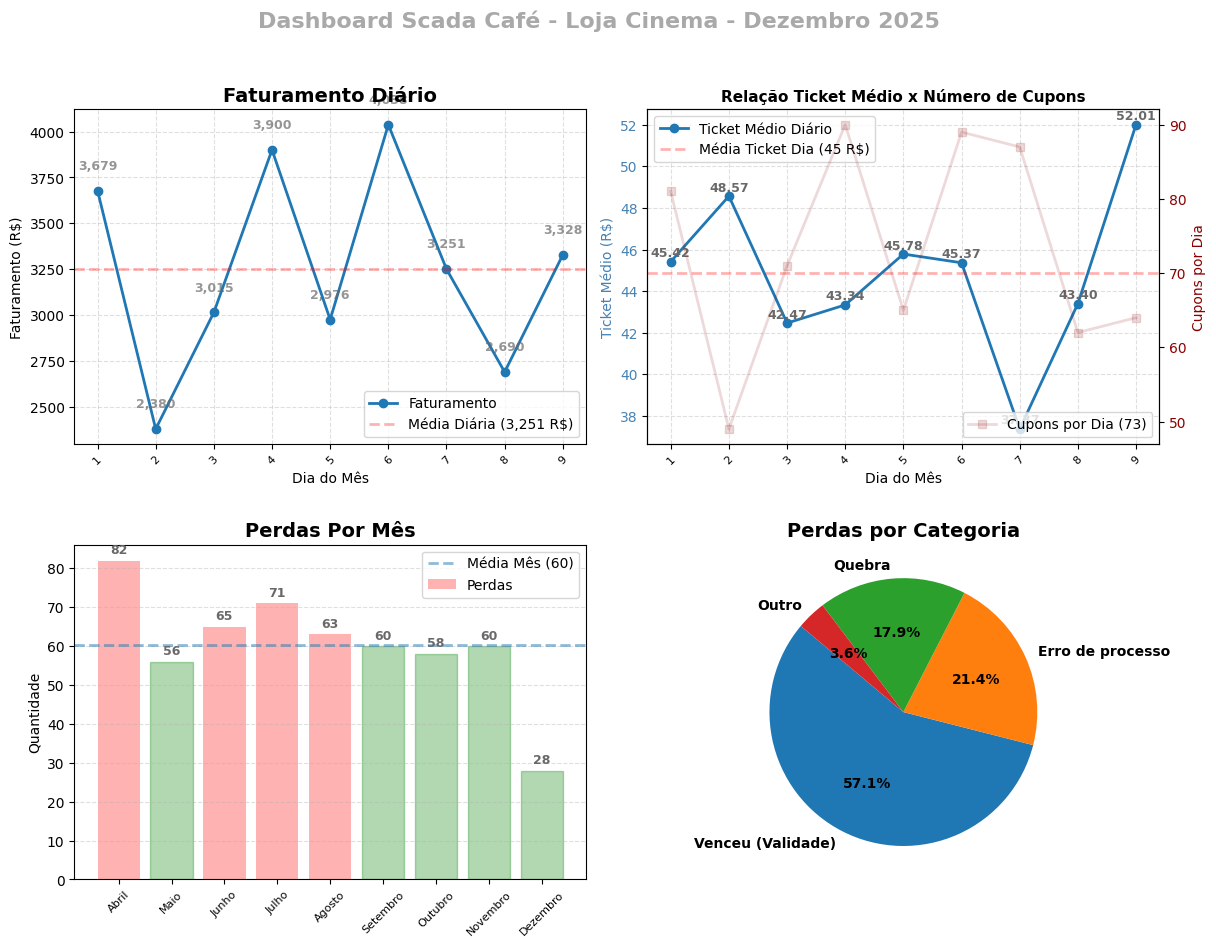

In [17]:
# Criação de Mosaico:
mosaico = "BC;DE" # Definição do mosaico onde serão alocados os gráficos
fig = plt.figure(figsize=(14, 10)) # Criação da figura dos gráficos
espacamento = {'wspace': 0.12, 'hspace': 0.3} # Variável para definição de espaçamentos
axs = fig.subplot_mosaic(mosaico, gridspec_kw=espacamento) # Criação do sistema de eixos


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO B:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# FATURAMENTO POR DIA:
# Agrupar por dia e somar o Faturamento
# Nota: Como já filtramos por mês, o 'Dia' aqui será o dia do mês (1, 2, 3...)
dados_diarios_mes = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Faturamento'].sum().reset_index()

# NOVIDADE CRUCIAL: FILTRAR APENAS DIAS COM FATURAMENTO MAIOR QUE ZERO
dados_diarios_mes = dados_diarios_mes[
    dados_diarios_mes['Faturamento'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# --- NOVIDADE: 1.4 Calcular a Média ---
media_diaria = dados_diarios_mes['Faturamento'].mean()

# .plot() é o comando para gráficos de linha
axs["B"].plot(
    dados_diarios_mes['Dia'],
    dados_diarios_mes['Faturamento'],
    marker='o',          # Adiciona um marcador para cada dia
    linestyle='-',       # Linha contínua
    linewidth=2,
    label="Faturamento"
)

# --- NOVIDADE: Linha de Média ---
axs["B"].axhline(
    y=media_diaria,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Diária ({media_diaria:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)

# --- NOVIDADE: Valores sobre os Pontos (Rótulos de Dados) ---
for dia, faturamento in zip(dados_diarios_mes['Dia'], dados_diarios_mes['Faturamento']):
    axs["B"].text(
        dia, 
        faturamento + 100,  # Adiciona um pequeno offset (+100) para ficar acima do ponto
        f"{faturamento:,.0f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',        # Alinhamento horizontal: centralizado no ponto
        va='bottom',        # Alinhamento vertical: acima do ponto
        fontsize=9,
        alpha=0.7,
        color='dimgrey',
        weight='bold'
    )

# --- 3. Personalização e Visualização ---
axs["B"].set_title(f'Faturamento Diário', fontsize=14, weight='bold')
axs["B"].set_xlabel('Dia do Mês', fontsize=10)
axs["B"].set_ylabel('Faturamento (R$)', fontsize=10)
axs["B"].set_xticklabels(dados_diarios_mes["Dia"], rotation=45, fontsize=8)

# Garantir que todos os dias do mês apareçam no eixo X
dias = range(1, len(dados_diarios_mes) + 1)
axs["B"].set_xticks(dias)

axs["B"].legend()
axs["B"].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Ajusta automaticamente o layout


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO C:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# RELAÇÃO TICKET MÉDIO X NÚMERO DE CUPONS:
# VARIÁVEIS TICKET: - - - - - - - - - - - - - - - - - - - - - - - - 
ticket_medio_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Ticket Médio'].mean().reset_index()
# Filtrar faturamento maior que '0':
ticket_medio_mes_corrente = ticket_medio_mes_corrente[
    ticket_medio_mes_corrente['Ticket Médio'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro
# Linha de Média
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()

# VARIÁVEIS CUPONS: - - - - - - - - - - - - - - - - - - - - - - - - 
dados_cupons_mes_corrente = df_mes_corrente.groupby(df_mes_corrente['Dia'].dt.day)['Cupons por Dia'].sum().reset_index()
#dados_cupons_mes_corrente.columns = ['Dia do Mês', 'Cupons por Dia']
# Filtrar cupos maior que '0':
dados_cupons_mes_corrente = dados_cupons_mes_corrente[dados_cupons_mes_corrente['Cupons por Dia'] > 0].reset_index(drop=True)
# O reset_index é opcional, mas boa prática após um filtro
# Calcular a Média de Cupons
media_cupons_mes_corrente = dados_cupons_mes_corrente['Cupons por Dia'].mean()

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

# CONSTRUÇÃO DO GRÁFICO COM DOIS EIXOS Y:
axs["C"].grid(True, linestyle='--', alpha=0.4)

# Primeiro eixo Y - Ticket Médio:
axs["C"].plot(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio'],
         marker='o', linestyle='-', linewidth=2, label='Ticket Médio Diário')
axs["C"].set_ylabel('Ticket Médio (R$)', color='steelblue')
axs["C"].set_xlabel('Dia do Mês', fontsize=10)
axs["C"].tick_params(axis='y', labelcolor="steelblue")
axs["C"].set_title(f'Relação Ticket Médio x Número de Cupons', fontsize=11, weight='bold')

# Linha de Média Ticket Médio:
media_ticket_mes_corrente = ticket_medio_mes_corrente['Ticket Médio'].mean()
axs["C"].axhline(
    y=media_ticket_mes_corrente,
    color='red',
    linestyle='--', # Linha tracejada
    alpha=0.3,
    linewidth=2,
    label=f"Média Ticket Dia ({media_ticket_mes_corrente:,.0f} R$)" # Adicionar label da média na legenda com o valor formatado
)
# Valores sobre os Pontos Ticket Médio (Rótulos de Dados):
for dia, ticket in zip(ticket_medio_mes_corrente['Dia'], ticket_medio_mes_corrente['Ticket Médio']):
    axs["C"].text(
        dia,
        ticket + 0.1,  # Adiciona um pequeno offset (+5) para ficar acima do ponto
        f"{ticket:,.2f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',
        va='bottom',
        fontsize=9,
        color='dimgrey',
        weight='bold'
    )

# - - - - - - - - - - - - - - - - - - - - - - - - - - -
ax2 = axs["C"].twinx()  # Criar um segundo eixo Y compartilhando o eixo X
# - - - - - - - - - - - - - - - - - - - - - - - - - - -

# Segundo eixo Y - Cupons por Dia:
ax2.plot(dados_cupons_mes_corrente['Dia'], dados_cupons_mes_corrente['Cupons por Dia'],
         marker='s', linestyle='-', color='darkred', linewidth=2, alpha=0.15, label=f'Cupons por Dia ({media_cupons_dia:.0f})')
ax2.set_ylabel('Cupons por Dia', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

#Ajuste de grid do gráfico de linhas para Cupons - AX2:
#ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.grid(False)

# Garantir que todos os dias do mês apareçam no eixo X
dias = range(1, len(dados_diarios_mes) + 1)
axs["C"].set_xticks(dias)
axs["C"].set_xticklabels(dados_cupons_mes_corrente["Dia"], rotation=45, fontsize=8)

# Adicionar legendas ancorando a posição fixa (x, y) / bbox_transform para posicionar em relação a área do gráfico
#axs["C"].legend(bbox_to_anchor=(0.65, 1), bbox_transform=axs["C"].transAxes)
axs["C"].legend(bbox_transform=ax2.transAxes)
ax2.legend()


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO D:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# PERDAS POR MÊS:
perdas_mes = axs["D"].bar(perdas_por_mes['Mês'], perdas_por_mes['Quantidade'], color='red', alpha=0.3, label='Perdas')
media_perdas_mes = perdas_por_mes['Quantidade'].mean()

# --- NOVIDADE: Linha de Média ---
axs["D"].axhline(
    y=media_perdas_mes,
    #color='salmon',
    linestyle='--', # Linha tracejada
    alpha=0.5,
    linewidth=2,
    label=f"Média Mês ({media_perdas_mes:,.0f})" # Adicionar label da média na legenda com o valor formatado
)

# === Personalização ===
axs["D"].set_title('Perdas Por Mês', fontsize=14, weight='bold')
#axs["D"].set_xlabel("Mês")
axs["D"].set_ylabel("Quantidade")
axs["D"].set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)
axs["D"].grid(False)
axs["D"].grid(axis="y", linestyle="--", alpha=0.4)
axs["D"].legend()

# === Valores sobre as barras ===
axs["D"].bar_label(
    perdas_mes, # Variável que recebeu a instrução do gráfico
    label=perdas_por_mes["Quantidade"], # Informação a ser exibida em cima de cada barra
    padding=3, # Posição do texto em relação à barra
    fontsize=9, # Tamanho da fonte
    fontweight='bold', # Fonte em negrito
    color="dimgrey" # Cor do texto
    )

# Muda a cor da barra para valores abaixo da média:
for i, barra in enumerate(perdas_mes):
    if perdas_por_mes["Quantidade"].iloc[i] < media_perdas_mes:
        barra.set_color('green')

# Destacar área no gráfico (exemplo: período de redução de perdas)
#plt.axvspan(4.5, 9.5, color='lightgreen', alpha=0.3) 
#plt.text(5.5, 70, 'Período de Redução de Perdas', fontsize=10, color='darkgreen')

plt.tight_layout() # Ajusta o layout automaticamente


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO E:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# PERDAS POR MOTIVO:
perdas_cat = axs["E"].pie(
    perdas_motivo['Item'],
    labels=perdas_motivo['Motivo'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10, 'weight': 'bold', 'color': 'black'}
)

# === Personalização ===
axs["E"].set_title(f'Perdas por Categoria', fontsize=14, weight='bold')

plt.tight_layout() # Ajusta o layout automaticamente


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# # AJUSTES FIGURA:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
fig.suptitle(f"Dashboard Scada Café - Loja Cinema - {nome_do_mes_corrente} 2025", fontsize=16, fontweight='bold', color='darkgrey')

# Gerar arquivo .PNG do gráfico:
plt.savefig("dashboard_Mes_Corrente.png", dpi=300, bbox_inches="tight")

plt.show()

### Dashboard Mês a Mês 2025:

/tmp/ipykernel_4213/4278746294.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["A"].set_xticklabels(faturamento_por_mes["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
/tmp/ipykernel_4213/4278746294.py:39: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs["A"].legend(loc="lower left")
/tmp/ipykernel_4213/4278746294.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_4213/4278746294.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Ajusta automaticamente o layout
/tmp/ipykernel_4213/4278746294.py:160: UserWarning: This figure includes Axes that are not c

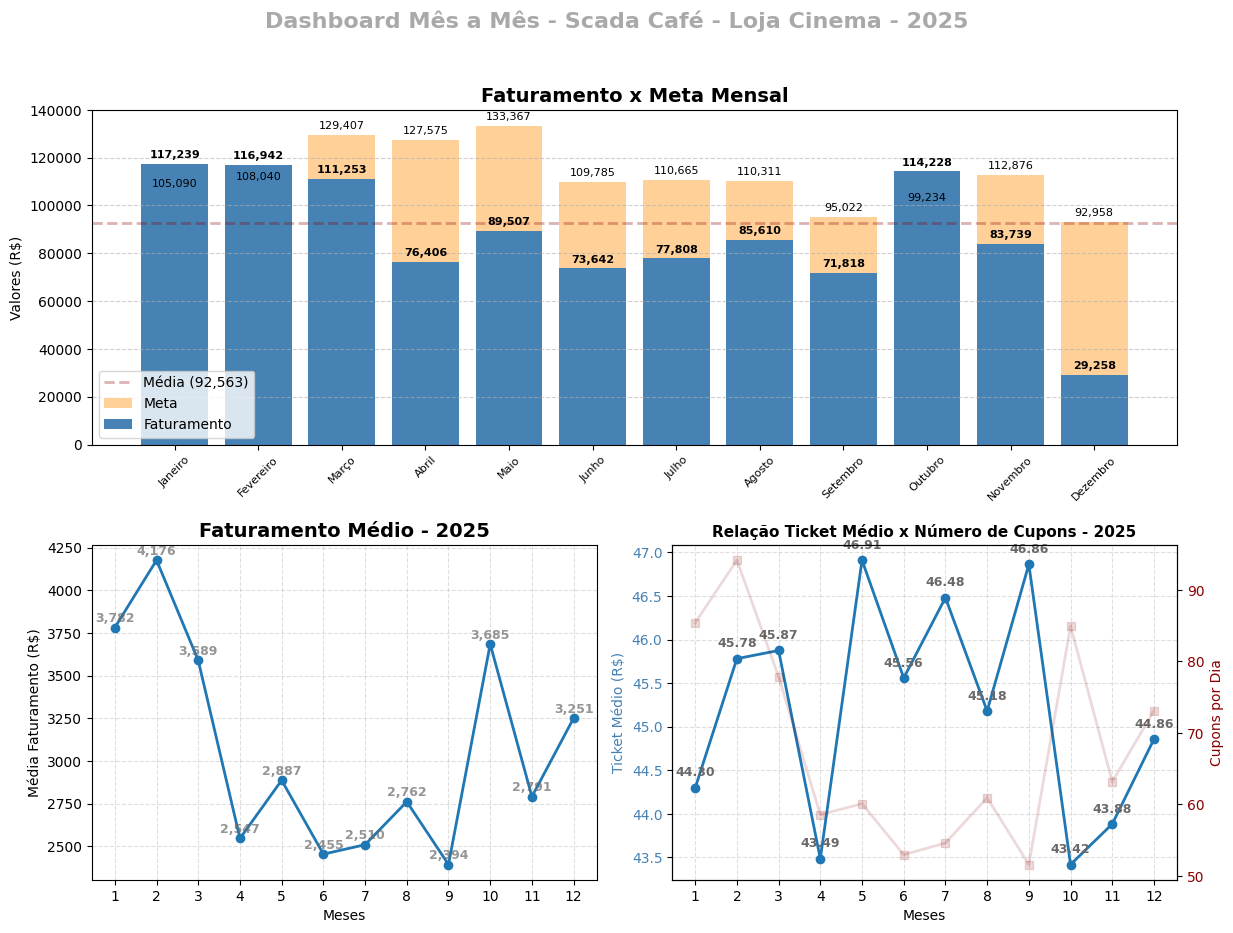

In [18]:
# Criação de Mosaico:
mosaico_mes = "AA;BC" # Definição do mosaico onde serão alocados os gráficos
fig = plt.figure(figsize=(14, 10)) # Criação da figura dos gráficos
espacamento = {'wspace': 0.15, 'hspace': 0.3} # Variável para definição de espaçamentos
axs = fig.subplot_mosaic(mosaico_mes, gridspec_kw=espacamento) # Criação do sistema de eixos

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO A:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# FATURAMENTO X META MENSAL:
faturamento_por_mes = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index()

media_faturamento_mes = faturamento_por_mes.loc[
    faturamento_por_mes["Mês"] != nome_do_mes_corrente, "Faturamento" # .loc[condição, coluna] → exclui esse mês.
].mean() # .mean() → calcula a média somente dos meses restantes.

# === Ordenar meses ===
faturamento_por_mes["Mês"] = pd.Categorical(faturamento_por_mes["Mês"],
                                     categories=ordem_meses,
                                     ordered=True)
faturamento_por_mes = faturamento_por_mes.sort_values("Mês")

# === Criar o gráfico de barras ===
barras_meta = axs["A"].bar(faturamento_por_mes["Mês"], faturamento_por_mes["Meta"], label="Meta", color="darkorange", alpha=0.4)
barras_faturamento = axs["A"].bar(faturamento_por_mes["Mês"], faturamento_por_mes["Faturamento"],label="Faturamento", color="steelblue")
axs["A"].bar_label(barras_meta, fmt="{:,.0f}", padding=3, fontsize=8, label='Meta')
axs["A"].bar_label(barras_faturamento, fmt="{:,.0f}", padding=3, fontsize=8, label='Faturamento', fontweight='bold')

# === Linha média ===
axs["A"].axhline(y=media_faturamento_mes, color="darkred", linestyle="--", alpha=0.3, linewidth=2,
            label=f"Média ({media_faturamento_mes:,.0f})")

# === Personalização ===
axs["A"].set_title("Faturamento x Meta Mensal", fontsize=14, weight='bold')
#ax.set_xlabel("Mês")
axs["A"].set_ylabel("Valores (R$)")
axs["A"].set_xticklabels(faturamento_por_mes["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
#ax.set_yticklabels(fontsize=8)
axs["A"].legend(loc="lower left")
axs["A"].grid(False)
axs["A"].grid(axis="y", linestyle="--", alpha=0.6)

#plt.savefig("faturamento_x_meta_mensal.png", dpi=300)

plt.tight_layout()


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO B:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# MÉDIA FATURAMENTO DIA (MÊS):
faturamento_por_dia = faturamento_df.groupby(faturamento_df['Dia'].dt.month)['Faturamento'].mean().reset_index().round(1)
faturamento_por_dia = faturamento_por_dia.rename(columns={'Dia': 'Mês'}) # Renomear coluna

# .plot() é o comando para gráficos de linha
axs["B"].plot(
    faturamento_por_dia['Mês'],
    faturamento_por_dia['Faturamento'],
    marker='o',          # Adiciona um marcador para cada dia
    linestyle='-',       # Linha contínua
    linewidth=2,
    label="Fat Médio Dia"
)

# --- NOVIDADE: Valores sobre os Pontos (Rótulos de Dados) ---
for dia, faturamento in zip(faturamento_por_dia['Mês'], faturamento_por_dia['Faturamento']):
    axs["B"].text(
        dia, 
        faturamento + 15,  # Adiciona um pequeno offset (+100) para ficar acima do ponto
        f"{faturamento:,.0f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',        # Alinhamento horizontal: centralizado no ponto
        va='bottom',        # Alinhamento vertical: acima do ponto
        fontsize=9,
        alpha=0.7,
        color='dimgrey',
        weight='bold'
    )

# --- 3. Personalização e Visualização ---
axs["B"].set_title('Faturamento Médio - 2025', fontsize=14, weight='bold')
axs["B"].set_xlabel('Meses', fontsize=10)
axs["B"].set_ylabel('Média Faturamento (R$)', fontsize=10)

# Garantir que todos os meses apareçam no eixo X:
dias = range(1, len(faturamento_por_dia) + 1)
axs["B"].set_xticks(dias)

#axs["B"].legend()
axs["B"].grid(False)
axs["B"].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout() # Ajusta automaticamente o layout


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO C:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# RELAÇÃO TICKET MÉDIO X NÚMERO DE CUPONS:
# VARIÁVEIS TICKET: - - - - - - - - - - - - - - - - - - - - - - - - 
ticket_medio_mes = faturamento_df.groupby(faturamento_df['Dia'].dt.month)['Ticket Médio'].mean().reset_index()
# Filtrar faturamento maior que '0':
ticket_medio_mes = ticket_medio_mes[
    ticket_medio_mes['Ticket Médio'] > 0
].reset_index(drop=True) # O reset_index é opcional, mas boa prática após um filtro

# VARIÁVEIS CUPONS: - - - - - - - - - - - - - - - - - - - - - - - - 
dados_cupons_mes = faturamento_df.groupby(faturamento_df['Dia'].dt.month)['Cupons por Dia'].mean().reset_index()
# Filtrar cupos maior que '0':
dados_cupons_mes = dados_cupons_mes[dados_cupons_mes['Cupons por Dia'] > 0].reset_index(drop=True)
# O reset_index é opcional, mas boa prática após um filtro

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

# CONSTRUÇÃO DO GRÁFICO COM DOIS EIXOS Y:

# Primeiro eixo Y - Ticket Médio:
axs["C"].plot(ticket_medio_mes['Dia'], ticket_medio_mes['Ticket Médio'],
         marker='o', linestyle='-', linewidth=2, label='Ticket Médio Diário')
axs["C"].set_ylabel('Ticket Médio (R$)', color='steelblue', fontsize=10)
axs["C"].tick_params(axis='y', labelcolor="steelblue")
axs["C"].set_title('Relação Ticket Médio x Número de Cupons - 2025', fontsize=11, weight='bold')
axs["C"].set_xlabel('Meses', fontsize=10)

# Valores sobre os Pontos Ticket Médio (Rótulos de Dados):
for dia, ticket in zip(ticket_medio_mes['Dia'], ticket_medio_mes['Ticket Médio']):
    axs["C"].text(
        dia,
        ticket + 0.1,  # Adiciona um pequeno offset (+5) para ficar acima do ponto
        f"{ticket:,.2f}", # Formata o valor sem casas decimais e com separador de milhar
        ha='center',
        va='bottom',
        fontsize=9,
        color='dimgrey',
        weight='bold'
    )

axs["C"].grid(True, linestyle='--', alpha=0.4)

# - - - - - - - - - - - - - - - - - - - - - - - - - - -
ax2 = axs["C"].twinx()  # Criar um segundo eixo Y compartilhando o eixo X
# - - - - - - - - - - - - - - - - - - - - - - - - - - -

# Segundo eixo Y - Cupons por Dia:
ax2.plot(dados_cupons_mes['Dia'], dados_cupons_mes['Cupons por Dia'],
         marker='s', linestyle='-', color='darkred', linewidth=2, alpha=0.15, label='Cupons por Dia')
ax2.set_ylabel('Cupons por Dia', color='darkred', fontsize=10)
ax2.tick_params(axis='y', labelcolor='darkred')

ax2.grid(False)

# Garantir que todos os dias de Outubro (1 a 31) apareçam no eixo X
#dias = range(1, len(dados_diarios_mes) + 1)
axs["C"].set_xticks(dias)

# Adicionar legendas ancorando a posição fixa (x, y) / bbox_transform para posicionar em relação a área do gráfico
#axs["C"].legend(bbox_to_anchor=(0.65, 1), bbox_transform=axs["C"].transAxes)
#axs["C"].legend(bbox_transform=ax2.transAxes)
#ax2.legend()

plt.tight_layout() # Ajusta automaticamente o layout


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# # AJUSTES FIGURA:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
fig.suptitle("Dashboard Mês a Mês - Scada Café - Loja Cinema - 2025", fontsize=16, fontweight='bold', color='darkgrey')

# Gerar arquivo .PNG do gráfico:
plt.savefig("dashboard_Mes_a_Mes.png", dpi=300, bbox_inches="tight")

plt.show()

### Mural de resultados:

/tmp/ipykernel_4213/3081884227.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["A"].set_xticklabels(faturamento_por_mes["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
/tmp/ipykernel_4213/3081884227.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_4213/3081884227.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs["B"].set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)
/tmp/ipykernel_4213/3081884227.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Ajusta o layout automaticamente
/tmp/ipykernel_4213/3081884227.py:122: UserWarning: This figure includes Axes that are not compatible with t

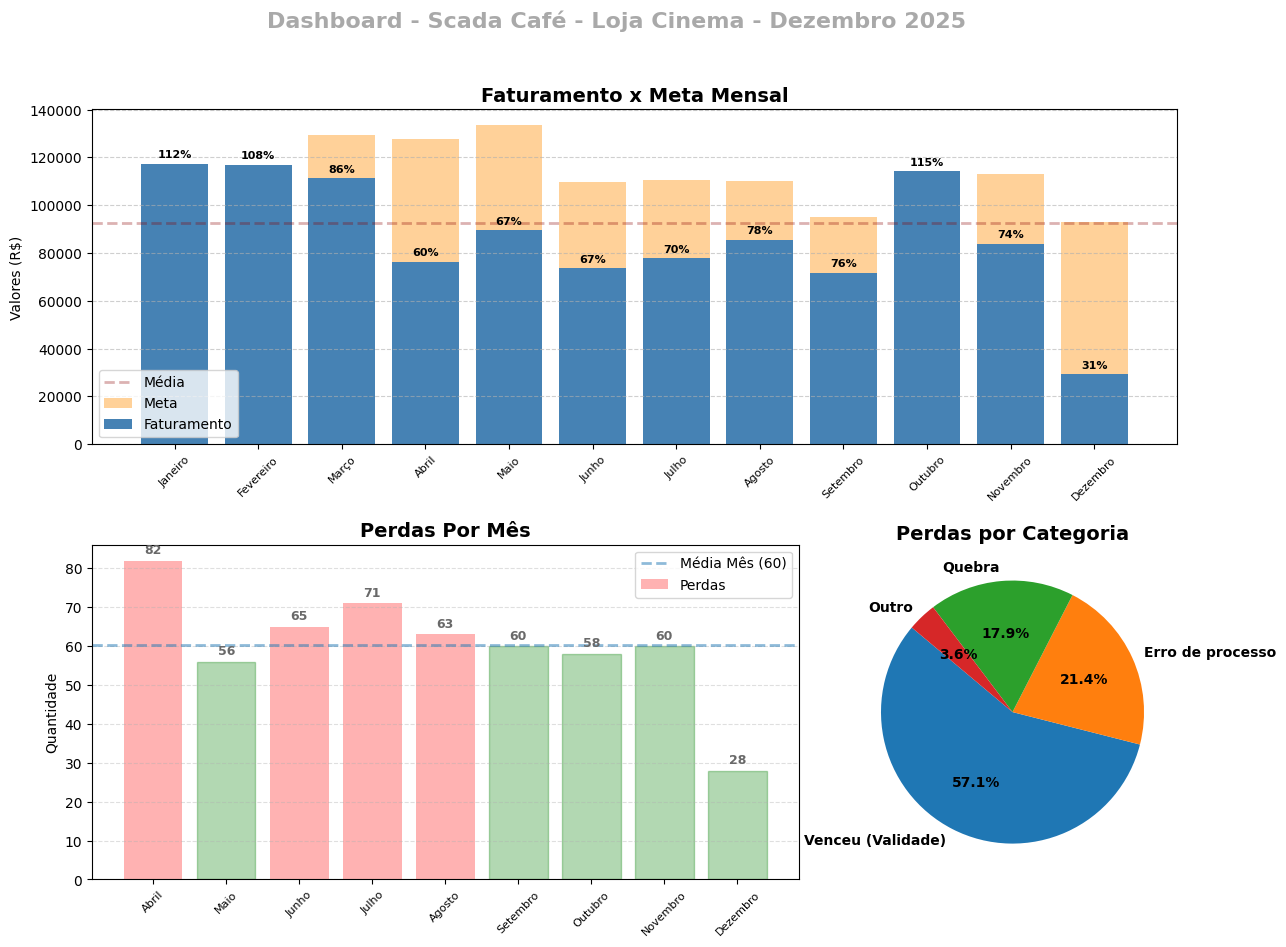

In [19]:
# Criação de Mosaico:
mosaico_mes = "AAA;BBC" # Definição do mosaico onde serão alocados os gráficos
fig = plt.figure(figsize=(14, 10)) # Criação da figura dos gráficos
espacamento = {'wspace': 0.15, 'hspace': 0.3} # Variável para definição de espaçamentos
axs = fig.subplot_mosaic(mosaico_mes, gridspec_kw=espacamento) # Criação do sistema de eixos

# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO A:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# FATURAMENTO X META MENSAL:
faturamento_por_mes = faturamento_df.groupby("Mês")[["Faturamento", "Meta"]].sum().reset_index()

media_faturamento_mes = faturamento_por_mes.loc[
    faturamento_por_mes["Mês"] != nome_do_mes_corrente, "Faturamento" # .loc[condição, coluna] → exclui esse mês.
].mean() # .mean() → calcula a média somente dos meses restantes.

# === Ordenar meses ===
faturamento_por_mes["Mês"] = pd.Categorical(faturamento_por_mes["Mês"],
                                     categories=ordem_meses,
                                     ordered=True)
faturamento_por_mes = faturamento_por_mes.sort_values("Mês")

# Calcular percentual atingido da meta
faturamento_por_mes["Percentual"] = faturamento_por_mes["Faturamento"] / faturamento_por_mes["Meta"]

# === Criar o gráfico de barras ===
barras_meta = axs["A"].bar(faturamento_por_mes["Mês"], faturamento_por_mes["Meta"], label="Meta", color="darkorange", alpha=0.4)
barras_faturamento = axs["A"].bar(faturamento_por_mes["Mês"], faturamento_por_mes["Faturamento"],label="Faturamento", color="steelblue")
#axs["A"].bar_label(barras_meta, fmt="{:,.0f}", padding=3, fontsize=8, label='Meta')

# Inserir rótulos com percentual sobre as barras de faturamento:
axs["A"].bar_label(
    barras_faturamento,
    labels=faturamento_por_mes["Percentual"].apply(lambda x: f"{x:.0%}"),
    padding=3,
    fontsize=8,
    fontweight='bold'
)

# === Linha média ===
axs["A"].axhline(y=media_faturamento_mes, color="darkred", linestyle="--", alpha=0.3, linewidth=2,
            label="Média")

# === Personalização ===
axs["A"].set_title("Faturamento x Meta Mensal", fontsize=14, weight='bold')
#ax.set_xlabel("Mês")
axs["A"].set_ylabel("Valores (R$)")
axs["A"].set_xticklabels(faturamento_por_mes["Mês"], rotation=45, fontsize=8) # rotation=45, fontsize=8
#ax.set_yticklabels(fontsize=8)
axs["A"].legend(loc="lower left")
axs["A"].grid(False)
axs["A"].grid(axis="y", linestyle="--", alpha=0.6)

#plt.savefig("faturamento_x_meta_mensal.png", dpi=300)

plt.tight_layout()


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO B:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# PERDAS POR MÊS:
perdas_mes = axs["B"].bar(perdas_por_mes['Mês'], perdas_por_mes['Quantidade'], color='red', alpha=0.3, label='Perdas')
media_perdas_mes = perdas_por_mes['Quantidade'].mean()

# --- NOVIDADE: Linha de Média ---
axs["B"].axhline(
    y=media_perdas_mes,
    #color='salmon',
    linestyle='--', # Linha tracejada
    alpha=0.5,
    linewidth=2,
    label=f"Média Mês ({media_perdas_mes:,.0f})" # Adicionar label da média na legenda com o valor formatado
)

# === Personalização ===
axs["B"].set_title('Perdas Por Mês', fontsize=14, weight='bold')
axs["B"].set_ylabel("Quantidade")
#axs["D"].set_xlabel("Mês")
axs["B"].grid(False)
axs["B"].set_xticklabels(perdas_por_mes["Mês"], rotation=45, fontsize=8)
axs["B"].grid(axis="y", linestyle="--", alpha=0.4)
axs["B"].legend()

# === Valores sobre as barras ===
axs["B"].bar_label(
    perdas_mes, # Variável que recebeu a instrução do gráfico
    label=perdas_por_mes["Quantidade"], # Informação a ser exibida em cima de cada barra
    padding=3, # Posição do texto em relação à barra
    fontsize=9, # Tamanho da fonte
    fontweight='bold', # Fonte em negrito
    color="dimgrey" # Cor do texto
    )

# Muda a cor da barra para valores abaixo da média:
for i, barra in enumerate(perdas_mes):
    if perdas_por_mes["Quantidade"].iloc[i] < media_perdas_mes:
        barra.set_color('green')

# Destacar área no gráfico (exemplo: período de redução de perdas)
#plt.axvspan(4.5, 9.5, color='lightgreen', alpha=0.3) 
#plt.text(5.5, 70, 'Período de Redução de Perdas', fontsize=10, color='darkgreen')

plt.tight_layout() # Ajusta o layout automaticamente


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# GRAFICO C:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# PERDAS POR MOTIVO:
perdas_cat = axs["C"].pie(
    perdas_motivo['Item'],
    labels=perdas_motivo['Motivo'],
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10, 'weight': 'bold', 'color': 'black'}
)

# === Personalização ===
axs["C"].set_title(f'Perdas por Categoria', fontsize=14, weight='bold')

plt.tight_layout() # Ajusta o layout automaticamente


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# # AJUSTES FIGURA:
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
fig.suptitle(f"Dashboard - Scada Café - Loja Cinema - {nome_do_mes_corrente} 2025", fontsize=16, fontweight='bold', color='darkgrey')

# Gerar arquivo .PNG do gráfico:
plt.savefig("dashboard_Mes_Mural.png", dpi=300, bbox_inches="tight")


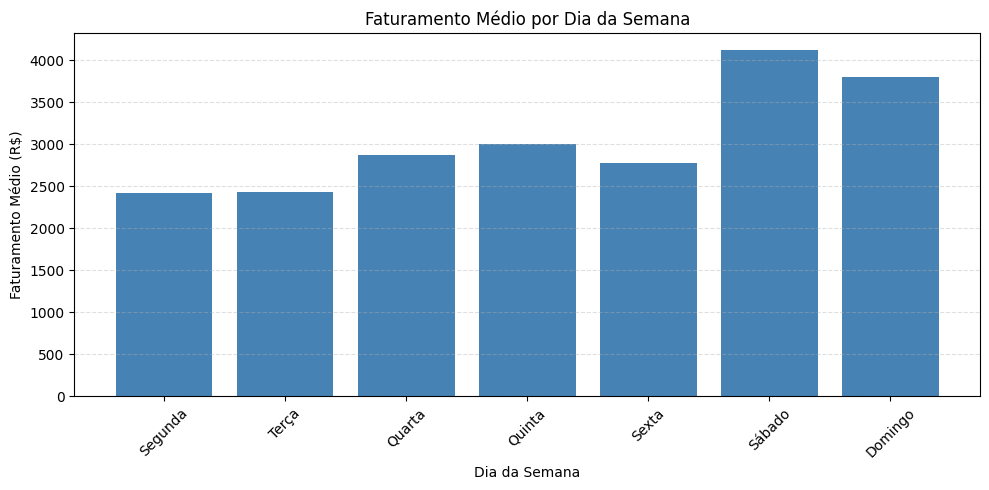

In [20]:
# Gráfico por dia da semana:
plt.figure(figsize=(10, 5))
plt.bar(faturamento_medio_semana["Dia Semana"],
        faturamento_medio_semana["Faturamento"],
        color="steelblue")

plt.title("Faturamento Médio por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Faturamento Médio (R$)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


### Gráficos com Seaborn

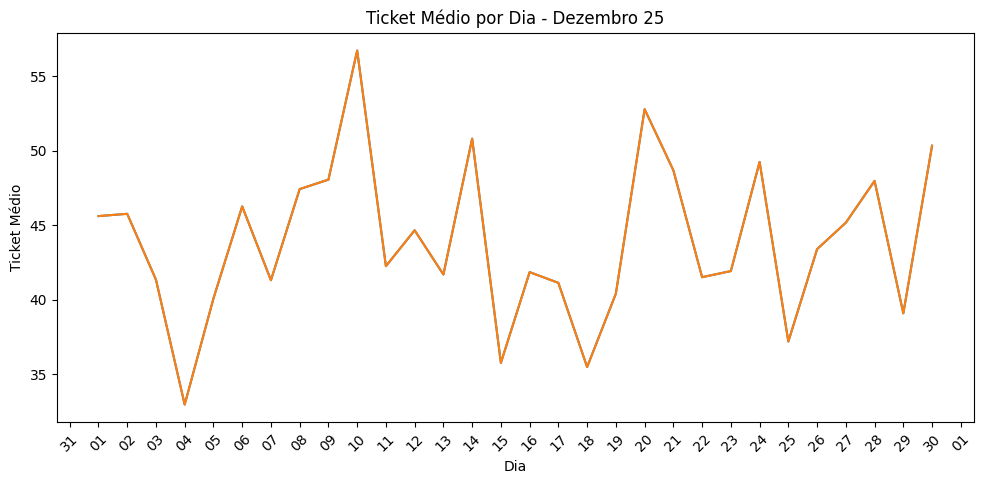

In [21]:
import seaborn as sns
import matplotlib.dates as mdates

# Filtrar mês corrente:
df_mes_corrente = faturamento_df[
    (faturamento_df['Dia'].dt.year == 2025) &
    (faturamento_df['Dia'].dt.month == 11)
]

# Exibir apenas valores maiores que zero:
df_mes_corrente = df_mes_corrente[df_mes_corrente["Ticket Médio"] > 0].reset_index(drop=True)
# O reset_index é opcional, mas boa prática após um filtro

# Agrupar dados DIA x Ticket:
ticket_medio_por_mes = df_mes_corrente.groupby("Dia")["Ticket Médio"].sum().reset_index()

plt.figure(figsize=(10, 5)) # Criação da figura dos gráficos

#Criar gráfico de linhas:
ticket_linhas = sns.lineplot(x="Dia", y="Ticket Médio", data=ticket_medio_por_mes) # Gráfico de linhas
# Exibir todos os dias no eixo X, além de exibir apenas o dia do mês (dois dígitos):
ticket_linhas.xaxis.set_major_locator(mdates.DayLocator())
ticket_linhas.xaxis.set_major_formatter(mdates.DateFormatter('%d'))

# Criar gráfico de linhas:
sns.set_theme(style="whitegrid")
ticket_linhas = sns.lineplot(x="Dia", y="Ticket Médio", data=ticket_medio_por_mes)
ticket_linhas.set_title(f"Ticket Médio por Dia - {nome_do_mes_corrente} 25")

# Opcional: ajustar rotação para evitar sobreposição
plt.xticks(rotation=45)
plt.tight_layout()



### Ler arquivos .txt

In [22]:
# Criando variável para abertura e leitura do arquivo:
arquivo = open('CxAbertura 2025-11-26 PDV 1 Aber 1.txt', 'r', encoding='latin1')
linhas = arquivo.readlines()

del linhas[:17]
del linhas[18:25]

#for linha in linhas:
#    item, valor = linha.split(':')
#    print(item)
#    print(valor)
#    if 'Venda Mesa' in item:
#        valor_venda = valor

#print(valor)


print(linhas)



['Venda Mesa.......:   5.713,01\n', 'Venda Cartao.....:       0,00\n', 'Venda Cliente....:       0,00\n', 'NF. Manual.......:       0,00\n', 'NF-e ............:       0,00\n', '                   ----------\n', 'Faturamento Bruto:   5.713,01\n', '(+) Tx. Entrega..:       0,00\n', '(+) Tx. Serv Mesa:     436,30\n', '(+) Tx. Serv Cart:       0,00\n', '(+) Couvert Mesa :       0,00\n', '(+) Couvert Cart.:       0,00\n', '(+) Estacionamen.:       0,00\n', '(+) Gorjeta......:       0,00\n', '(+) Emissao CVale:       0,00\n', '(+) Suprimento...:       0,00\n', '(+) Doacao.......:       0,00\n', '(+) Pagto Cliente:       0,00\n', '* Canc. Adminis:       0,00\n', '================================================================================\n', '                         *** CONTAGEM DE NUMERARIOS ***\n', 'Tipo Pagto            Sistema   %      Manual   %\n', 'DINHEIRO               483,38   7,87   420,25   6,84\n', 'VISA CREDITO          1090,19  17,75  1166,68  18,99\n', 'MASTERCARD CREDIT